##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [1]:
import os
from collections import Counter

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import numpy as np
import torch
import torch.nn.functional as F
import sklearn.cluster._kmeans as sklearn_kmeans
from contextlib import nullcontext
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from torchvision.datasets import OxfordIIITPet
from transformers import AutoImageProcessor, AutoModel

sklearn_kmeans.threadpool_info = lambda: []
sklearn_kmeans.threadpool_limits = lambda *args, **kwargs: nullcontext()

DINO_MODEL = "facebook/dinov2-small"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained(DINO_MODEL)
encoder = AutoModel.from_pretrained(DINO_MODEL).to(DEVICE)
encoder.eval()

pets = OxfordIIITPet(
    root="data/oxford-iiit-pet",
    split="trainval",
    target_types="category",
    download=True,
)

cat_breeds = {
    "Abyssinian", "Bengal", "Birman", "Bombay", "British Shorthair", "Egyptian Mau",
    "Maine Coon", "Persian", "Ragdoll", "Russian Blue", "Siamese", "Sphynx",
}

def label_from_category(category_id):
    breed = pets.classes[category_id]
    return "cat" if breed in cat_breeds else "dog"

def choose_balanced_samples(dataset, samples_per_group=10):
    chosen = []
    totals = Counter()
    seen_breeds = {"cat": set(), "dog": set()}

    for image, category_id in dataset:
        breed = dataset.classes[category_id]
        label = label_from_category(category_id)
        if totals[label] >= samples_per_group or breed in seen_breeds[label]:
            continue

        chosen.append({"image": image.convert("RGB"), "label": label, "breed": breed})
        totals[label] += 1
        seen_breeds[label].add(breed)

        if totals["cat"] == samples_per_group and totals["dog"] == samples_per_group:
            return chosen

    raise RuntimeError("Could not build a balanced cat/dog subset from Oxford-IIIT Pet.")

@torch.no_grad()
def cls_embedding(pil_image):
    batch = processor(images=pil_image, return_tensors="pt").to(DEVICE)
    hidden = encoder(**batch).last_hidden_state
    cls = hidden[:, 0, :]
    return F.normalize(cls, dim=1).cpu().numpy()[0]

examples = choose_balanced_samples(pets)
features = np.vstack([cls_embedding(item["image"]) for item in examples])
y_true_text = np.array([item["label"] for item in examples])
y_true = np.where(y_true_text == "cat", 0, 1)

clusterer = KMeans(n_clusters=2, random_state=11, n_init=10)
raw_clusters = clusterer.fit_predict(features)

cluster_name = {}
for cluster_id in sorted(set(raw_clusters)):
    labels_inside = y_true[raw_clusters == cluster_id]
    cluster_name[cluster_id] = int(Counter(labels_inside).most_common(1)[0][0])

y_pred = np.array([cluster_name[c] for c in raw_clusters])
y_pred_text = np.where(y_pred == 0, "cat", "dog")

print(f"Feature matrix shape: {features.shape}")
print(f"Class balance: {dict(Counter(y_true_text))}")
print(f"K-Means accuracy after majority-vote cluster mapping: {accuracy_score(y_true, y_pred):.2%}")
print("Confusion matrix rows=true [cat, dog], columns=predicted [cat, dog]:")
print(confusion_matrix(y_true, y_pred, labels=[0, 1]))
print("\nClassification report:")  # ← هنا كان الخطأ
print(classification_report(y_true_text, y_pred_text, labels=["cat", "dog"]))

for number, item in enumerate(examples, start=1):
    print(
        f"{number:02d}. {item['breed']:24s} true={item['label']:3s} "
        f"cluster={raw_clusters[number - 1]} predicted={y_pred_text[number - 1]}"
    )

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

100%|██████████| 792M/792M [00:54<00:00, 14.7MB/s] 
100%|██████████| 19.2M/19.2M [00:01<00:00, 12.4MB/s]


Feature matrix shape: (20, 384)
Class balance: {np.str_('cat'): 10, np.str_('dog'): 10}
K-Means accuracy after majority-vote cluster mapping: 95.00%
Confusion matrix rows=true [cat, dog], columns=predicted [cat, dog]:
[[ 9  1]
 [ 0 10]]

Classification report:
              precision    recall  f1-score   support

         cat       1.00      0.90      0.95        10
         dog       0.91      1.00      0.95        10

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95        20
weighted avg       0.95      0.95      0.95        20

01. Abyssinian               true=cat cluster=1 predicted=cat
02. American Bulldog         true=dog cluster=0 predicted=dog
03. American Pit Bull Terrier true=dog cluster=0 predicted=dog
04. Basset Hound             true=dog cluster=0 predicted=dog
05. Beagle                   true=dog cluster=0 predicted=dog
06. Bengal                   true=cat cluster=1 predicted=cat
07. Birman                   true=cat c

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

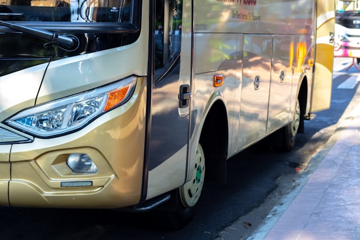

Image URL: https://images.unsplash.com/photo-1557223562-6c77ef16210f?w=640
Top-5 ImageNet predictions:
1. recreational vehicle, RV, R.V.: 34.88%
2. ambulance: 27.34%
3. passenger car, coach, carriage: 15.40%
4. minibus: 5.27%
5. tow truck, tow car, wrecker: 4.36%


In [6]:
import requests
import torch
from io import BytesIO
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification

MODEL_WITH_HEAD = "facebook/dinov2-small-imagenet1k-1-layer"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

processor_cls = AutoImageProcessor.from_pretrained(MODEL_WITH_HEAD)
classifier = AutoModelForImageClassification.from_pretrained(MODEL_WITH_HEAD).to(DEVICE)
classifier.eval()

# Online ImageNet-style example: a school bus.
image_url = "https://images.unsplash.com/photo-1557223562-6c77ef16210f?w=640"
img_bytes = requests.get(image_url, timeout=20, headers={"User-Agent": "Mozilla/5.0"})
img_bytes.raise_for_status()
query_image = Image.open(BytesIO(img_bytes.content)).convert("RGB")

display(query_image.resize((360, 240)))

model_inputs = processor_cls(images=query_image, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    output = classifier(**model_inputs)
    scores = torch.softmax(output.logits, dim=-1)[0]
    probabilities, class_ids = scores.topk(5)

print(f"Image URL: {image_url}")
print("Top-5 ImageNet predictions:")
for rank, (class_id, probability) in enumerate(zip(class_ids.tolist(), probabilities.tolist()), start=1):
    class_name = classifier.config.id2label[class_id]
    print(f"{rank}. {class_name}: {probability:.2%}")